In [1]:
from google.colab import files

uploaded = files.upload()

Saving IRIS.csv to IRIS.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('IRIS.csv')

print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (150, 5)

Column Names:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
print("Flower Species:")
print(df['species'].value_counts())

Flower Species:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


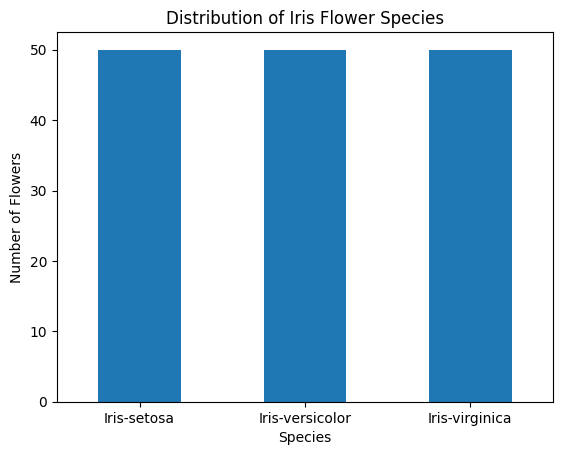

In [6]:
df['species'].value_counts().plot(
    kind='bar',
    title='Distribution of Iris Flower Species'
)

plt.xlabel('Species')
plt.ylabel('Number of Flowers')
plt.xticks(rotation=0)
plt.show()

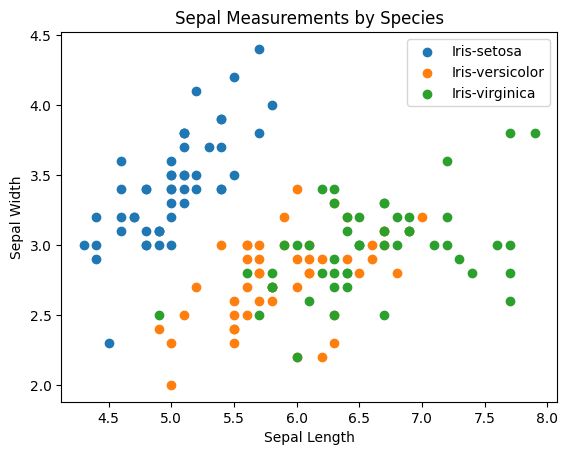

In [7]:
for species in df['species'].unique():
    subset = df[df['species'] == species]

    plt.scatter(
        subset['sepal_length'],
        subset['sepal_width'],
        label=species
    )

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Sepal Measurements by Species')
plt.legend()
plt.show()

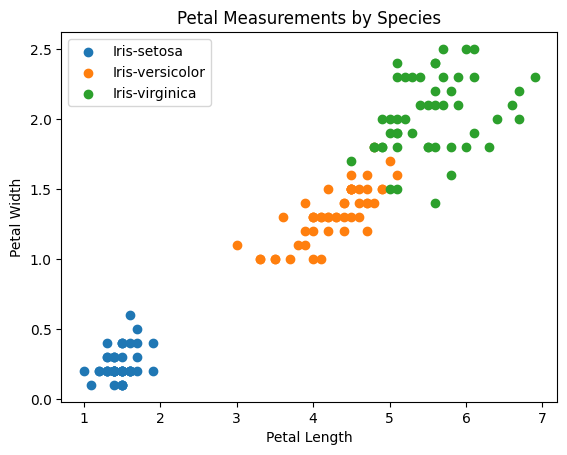

In [8]:
for species in df['species'].unique():
    subset = df[df['species'] == species]

    plt.scatter(
        subset['petal_length'],
        subset['petal_width'],
        label=species
    )

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Petal Measurements by Species')
plt.legend()
plt.show()

In [9]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows: 3
Dataset shape after removing duplicates: (147, 5)


In [10]:
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [11]:
label_encoder = LabelEncoder()

df['species_encoded'] = label_encoder.fit_transform(df['species'])

print("Species Mapping:")

for number, species in enumerate(label_encoder.classes_):
    print(number, "=", species)

display(df.head())

Species Mapping:
0 = Iris-setosa
1 = Iris-versicolor
2 = Iris-virginica


,sepal_length,sepal_width,petal_length,petal_width,species,species_encoded
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [12]:
X = df[
    [
        'sepal_length',
        'sepal_width',
        'petal_length',
        'petal_width'
    ]
]

y = df['species_encoded']

print("Features:")
display(X.head())

print("Target:")
display(y.head())

Features:


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Target:


,species_encoded
0,0
1,0
2,0
3,0
4,0


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (117, 4)
Testing Data Shape: (30, 4)


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC()
}

results = {}

for name, model in models.items():

    if name in ['Logistic Regression', 'KNN', 'SVM']:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print(name)
    print("Accuracy:", round(accuracy * 100, 2), "%")
    print("-" * 40)

Logistic Regression
Accuracy: 93.33 %
----------------------------------------
Decision Tree
Accuracy: 93.33 %
----------------------------------------
Random Forest
Accuracy: 96.67 %
----------------------------------------
KNN
Accuracy: 93.33 %
----------------------------------------
SVM
Accuracy: 96.67 %
----------------------------------------


In [16]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=['Model', 'Accuracy']
)

results_df['Accuracy (%)'] = results_df['Accuracy'] * 100

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

display(results_df)

,Model,Accuracy,Accuracy (%)
2,Random Forest,0.966667,96.666667
4,SVM,0.966667,96.666667
0,Logistic Regression,0.933333,93.333333
1,Decision Tree,0.933333,93.333333
3,KNN,0.933333,93.333333


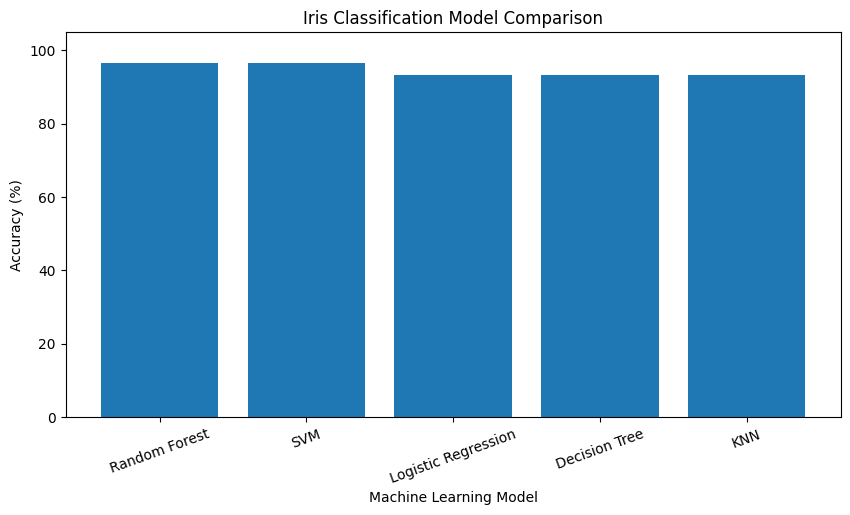

In [17]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df['Model'],
    results_df['Accuracy (%)']
)

plt.title('Iris Classification Model Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.xticks(rotation=20)

plt.show()

In [18]:
final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print(
    "Final Model Accuracy:",
    round(accuracy_score(y_test, y_pred) * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Final Model Accuracy: 96.67 %

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



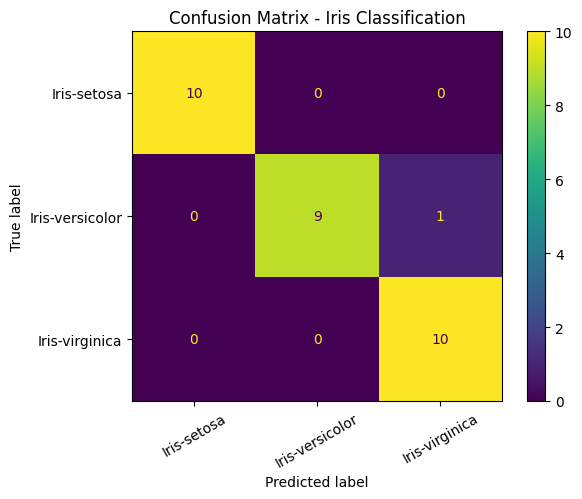

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_encoder.classes_
)

plt.title('Confusion Matrix - Iris Classification')
plt.xticks(rotation=30)
plt.show()

,Feature,Importance
2,petal_length,0.443075
3,petal_width,0.414662
0,sepal_length,0.121489
1,sepal_width,0.020774


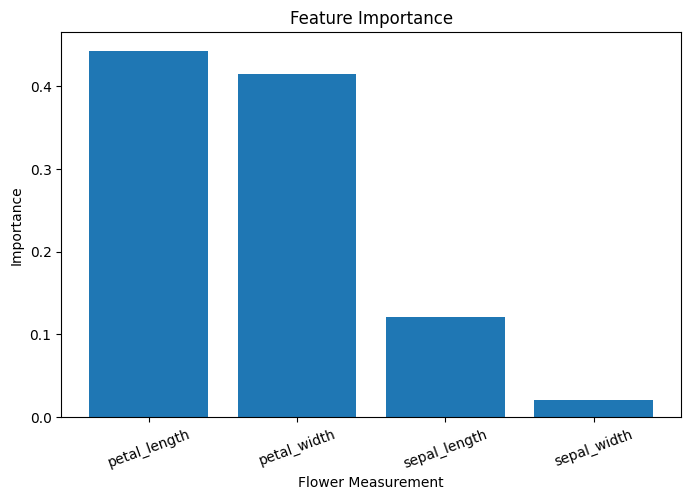

In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

display(importance)

plt.figure(figsize=(8, 5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance')
plt.xlabel('Flower Measurement')
plt.ylabel('Importance')
plt.xticks(rotation=20)

plt.show()

In [21]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        'sepal_length',
        'sepal_width',
        'petal_length',
        'petal_width'
    ]
)

prediction = final_model.predict(new_flower)

predicted_species = label_encoder.inverse_transform(prediction)

print("Predicted Iris Species:", predicted_species[0])

Predicted Iris Species: Iris-setosa


Conclusion

In this project, the Iris flower dataset was analyzed and used to develop machine-learning classification models capable of predicting Iris species based on sepal and petal measurements. Multiple algorithms, including Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, and Support Vector Machine, were trained and compared. The models achieved high classification accuracy, demonstrating that flower measurements can effectively distinguish between Iris setosa, Iris versicolor, and Iris virginica.